### Satellite Image Classification

### Import necessary libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow import keras
from sklearn.utils import shuffle
from skimage.transform import resize
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import glob


### Fetch the image Data

In [2]:
cloudy = glob.glob('data/cloudy/*.jpg')
desert = glob.glob('data/desert/*.jpg')
green_area = glob.glob('data/green_area/*.jpg')
water = glob.glob('data/water/*.jpg')

In [3]:
len(cloudy)

1500

In [4]:
len(desert)

1131

In [5]:
len(green_area)

1500

In [6]:
len(water)

1500

### Store all the images inside a list and create a list with the corresponding labels

In [7]:
image = []
label = []
for i in cloudy:
    img = plt.imread(i)
    image.append(img)
    label.append(0)

for i in desert:
    img = plt.imread(i)
    image.append(img)
    label.append(1)

for i in green_area:
    img = plt.imread(i)
    image.append(img)
    label.append(2)

for i in water:
    img = plt.imread(i)
    image.append(img)
    label.append(3)


#### Use shuffle function from sklearn utils

In [8]:
image, label = shuffle(image,label, random_state = 100)

### Plot a few images from our shuffled list with its corresponding label 

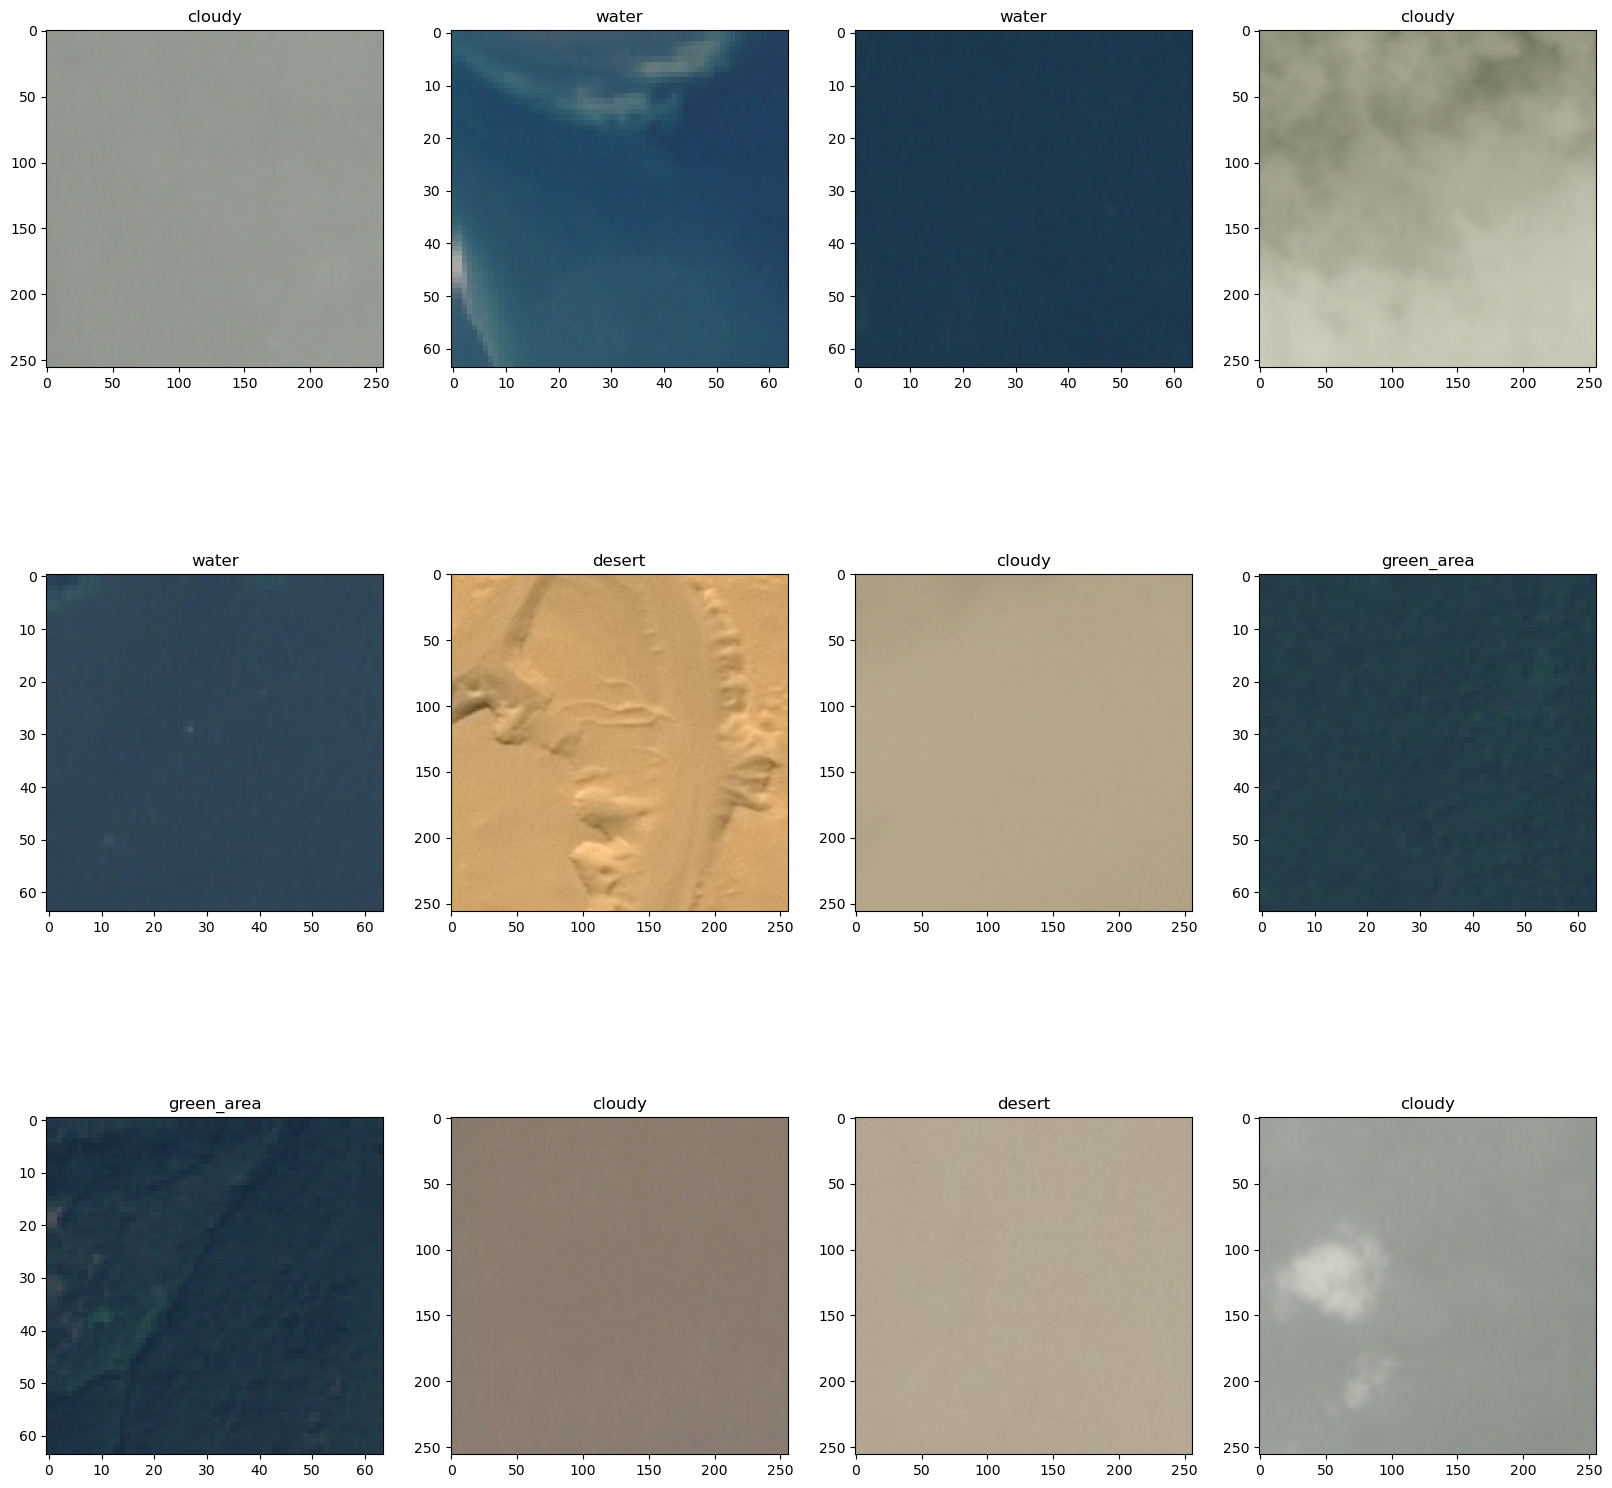

In [9]:
plt.figure(figsize = (20,20))
for i in range(12):
    plt.subplot(3,4,i+1)
    plt.imshow(image[i])
    if label[i] == 3:
        plt.title('water')
    elif label[i] == 2:
        plt.title('green_area')
    elif label[i] == 1:
        plt.title('desert')
    elif label[i] == 0:
        plt.title('cloudy')

### Resize the images to 64X64

In [26]:
X = []

for i in image:
    X.append(resize(i,(64,64,3)))
    
X = np.array(X)

### Plot some of the resized images

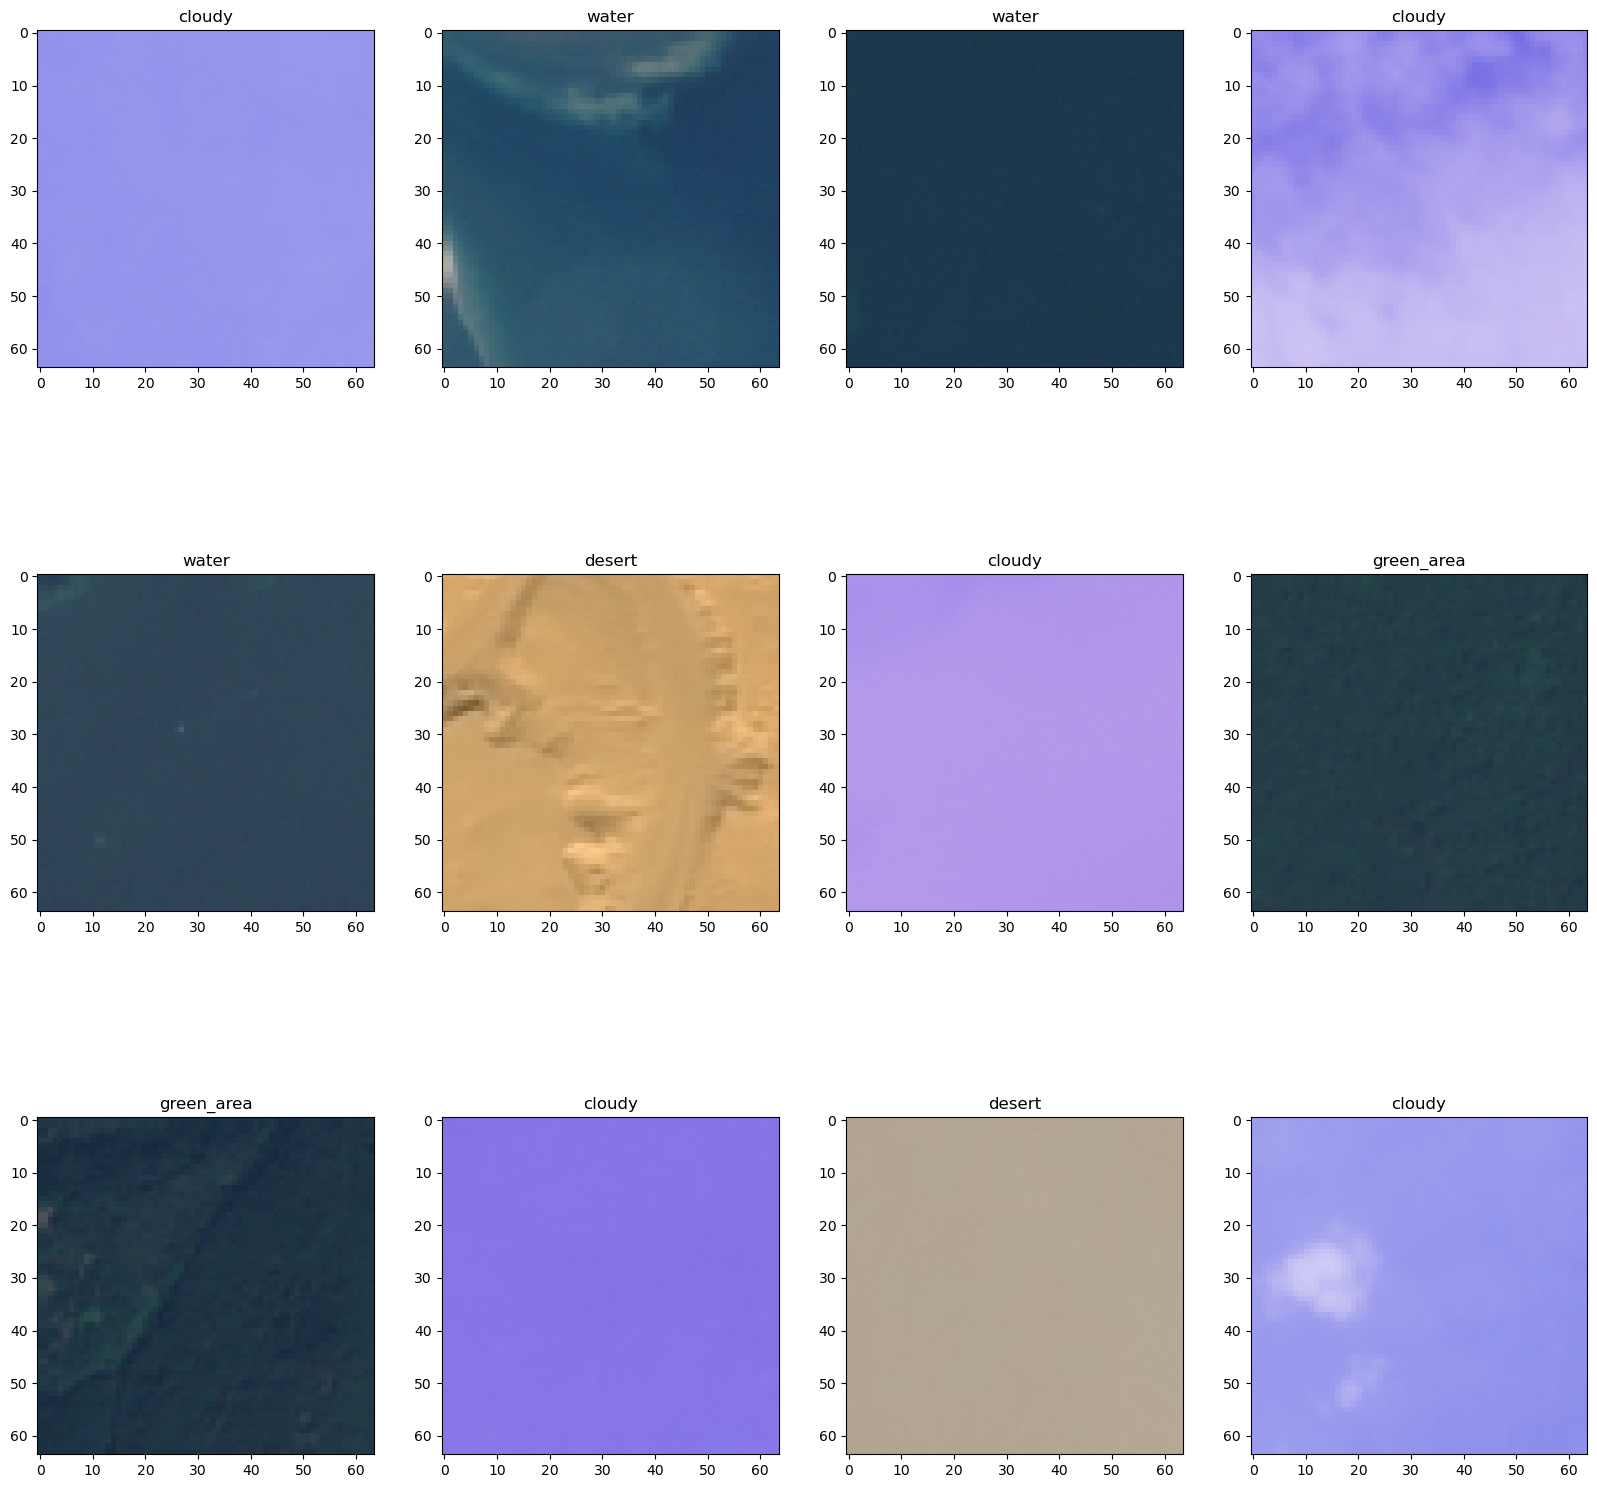

In [27]:
plt.figure(figsize = (20,20))
for i in range(12):
    plt.subplot(3,4,i+1)
    plt.imshow(X[i])
    if label[i] == 3:
        plt.title('water')
    elif label[i] == 2:
        plt.title('green_area')
    elif label[i] == 1:
        plt.title('desert')
    elif label[i] == 0:
        plt.title('cloudy')

### Check the datatype of X and Label

In [28]:
print(type(X))
print(type(label))

<class 'numpy.ndarray'>
<class 'list'>


In [29]:
y = np.array(label)

### Split the dataset into Training and Testing set

In [30]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size= 0.2)

In [31]:
model = keras.models.Sequential([
    keras.layers.Conv2D(16, (3,3), activation = 'relu', input_shape = (64, 64, 3)),
    keras.layers.MaxPool2D(2,2),
    
    keras.layers.Conv2D(32,(3,3), activation = 'relu'),
    keras.layers.MaxPool2D(2,2),
    
    keras.layers.Flatten(),
    
    keras.layers.Dense(64, activation = 'relu'),
    keras.layers.Dense(4, activation = 'softmax')
])

### Compile the model

In [32]:
model.compile(optimizer = 'adam',
             loss = 'sparse_categorical_crossentropy',
             metrics = ['accuracy'])

### Check the summary of our model

In [33]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)                    │ (None, 62, 62, 16)          │             448 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_4 (MaxPooling2D)       │ (None, 31, 31, 16)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 29, 29, 32)          │           4,640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_5 (MaxPooling2D)       │ (None, 14, 14, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_2 (Flatten)                  │ (None, 6272)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 64)                  │         401,472 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 4)                   │             260 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 406,820 (1.55 MB)

 Trainable params: 406,820 (1.55 MB)

 Non-trainable params: 0 (0.00 B)

### Train our model with X_train and y_train

In [34]:
model.fit(X_train,y_train, epochs=5, steps_per_epoch=20, validation_split=0.1)

Epoch 1/5
20/20 ━━━━━━━━━━━━━━━━━━━━ 7s 150ms/step - accuracy: 0.4397 - loss: 1.0526 - val_accuracy: 0.7317 - val_loss: 0.6871
Epoch 2/5
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 115ms/step - accuracy: 0.8189 - loss: 0.4483 - val_accuracy: 0.8337 - val_loss: 0.3310
Epoch 3/5
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 106ms/step - accuracy: 0.8850 - loss: 0.2589 - val_accuracy: 0.9224 - val_loss: 0.2146
Epoch 4/5
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 106ms/step - accuracy: 0.9104 - loss: 0.2052 - val_accuracy: 0.9135 - val_loss: 0.2251
Epoch 5/5
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 105ms/step - accuracy: 0.9075 - loss: 0.2045 - val_accuracy: 0.9180 - val_loss: 0.1881


### Evaluate our Model

In [35]:
model.evaluate(X_train,y_train)

141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9127 - loss: 0.1949 


[0.19488264620304108, 0.9127442240715027]

### Make predictions with X_test

In [36]:
prediction = model.predict(X_test)

36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step 


In [37]:
prediction[:5]

array([[8.5112697e-05, 6.9135999e-06, 8.8915461e-01, 1.1075339e-01],
       [4.7628894e-03, 5.7404634e-07, 5.1055063e-04, 9.9472600e-01],
       [9.9959368e-01, 1.8753938e-07, 4.0617839e-12, 4.0617265e-04],
       [9.9945956e-01, 2.7645150e-05, 6.4131767e-13, 5.1281898e-04],
       [7.7367331e-06, 9.9998593e-01, 3.9235754e-12, 6.2772574e-06]],
      dtype=float32)

### Use np.argmax to fetch indices of max element of the array

In [39]:
y_pred = [int(np.argmax(i))for i in prediction]

In [40]:
y_pred[:5]

[2, 3, 0, 0, 1]

### Plot X_test with label from our prediction

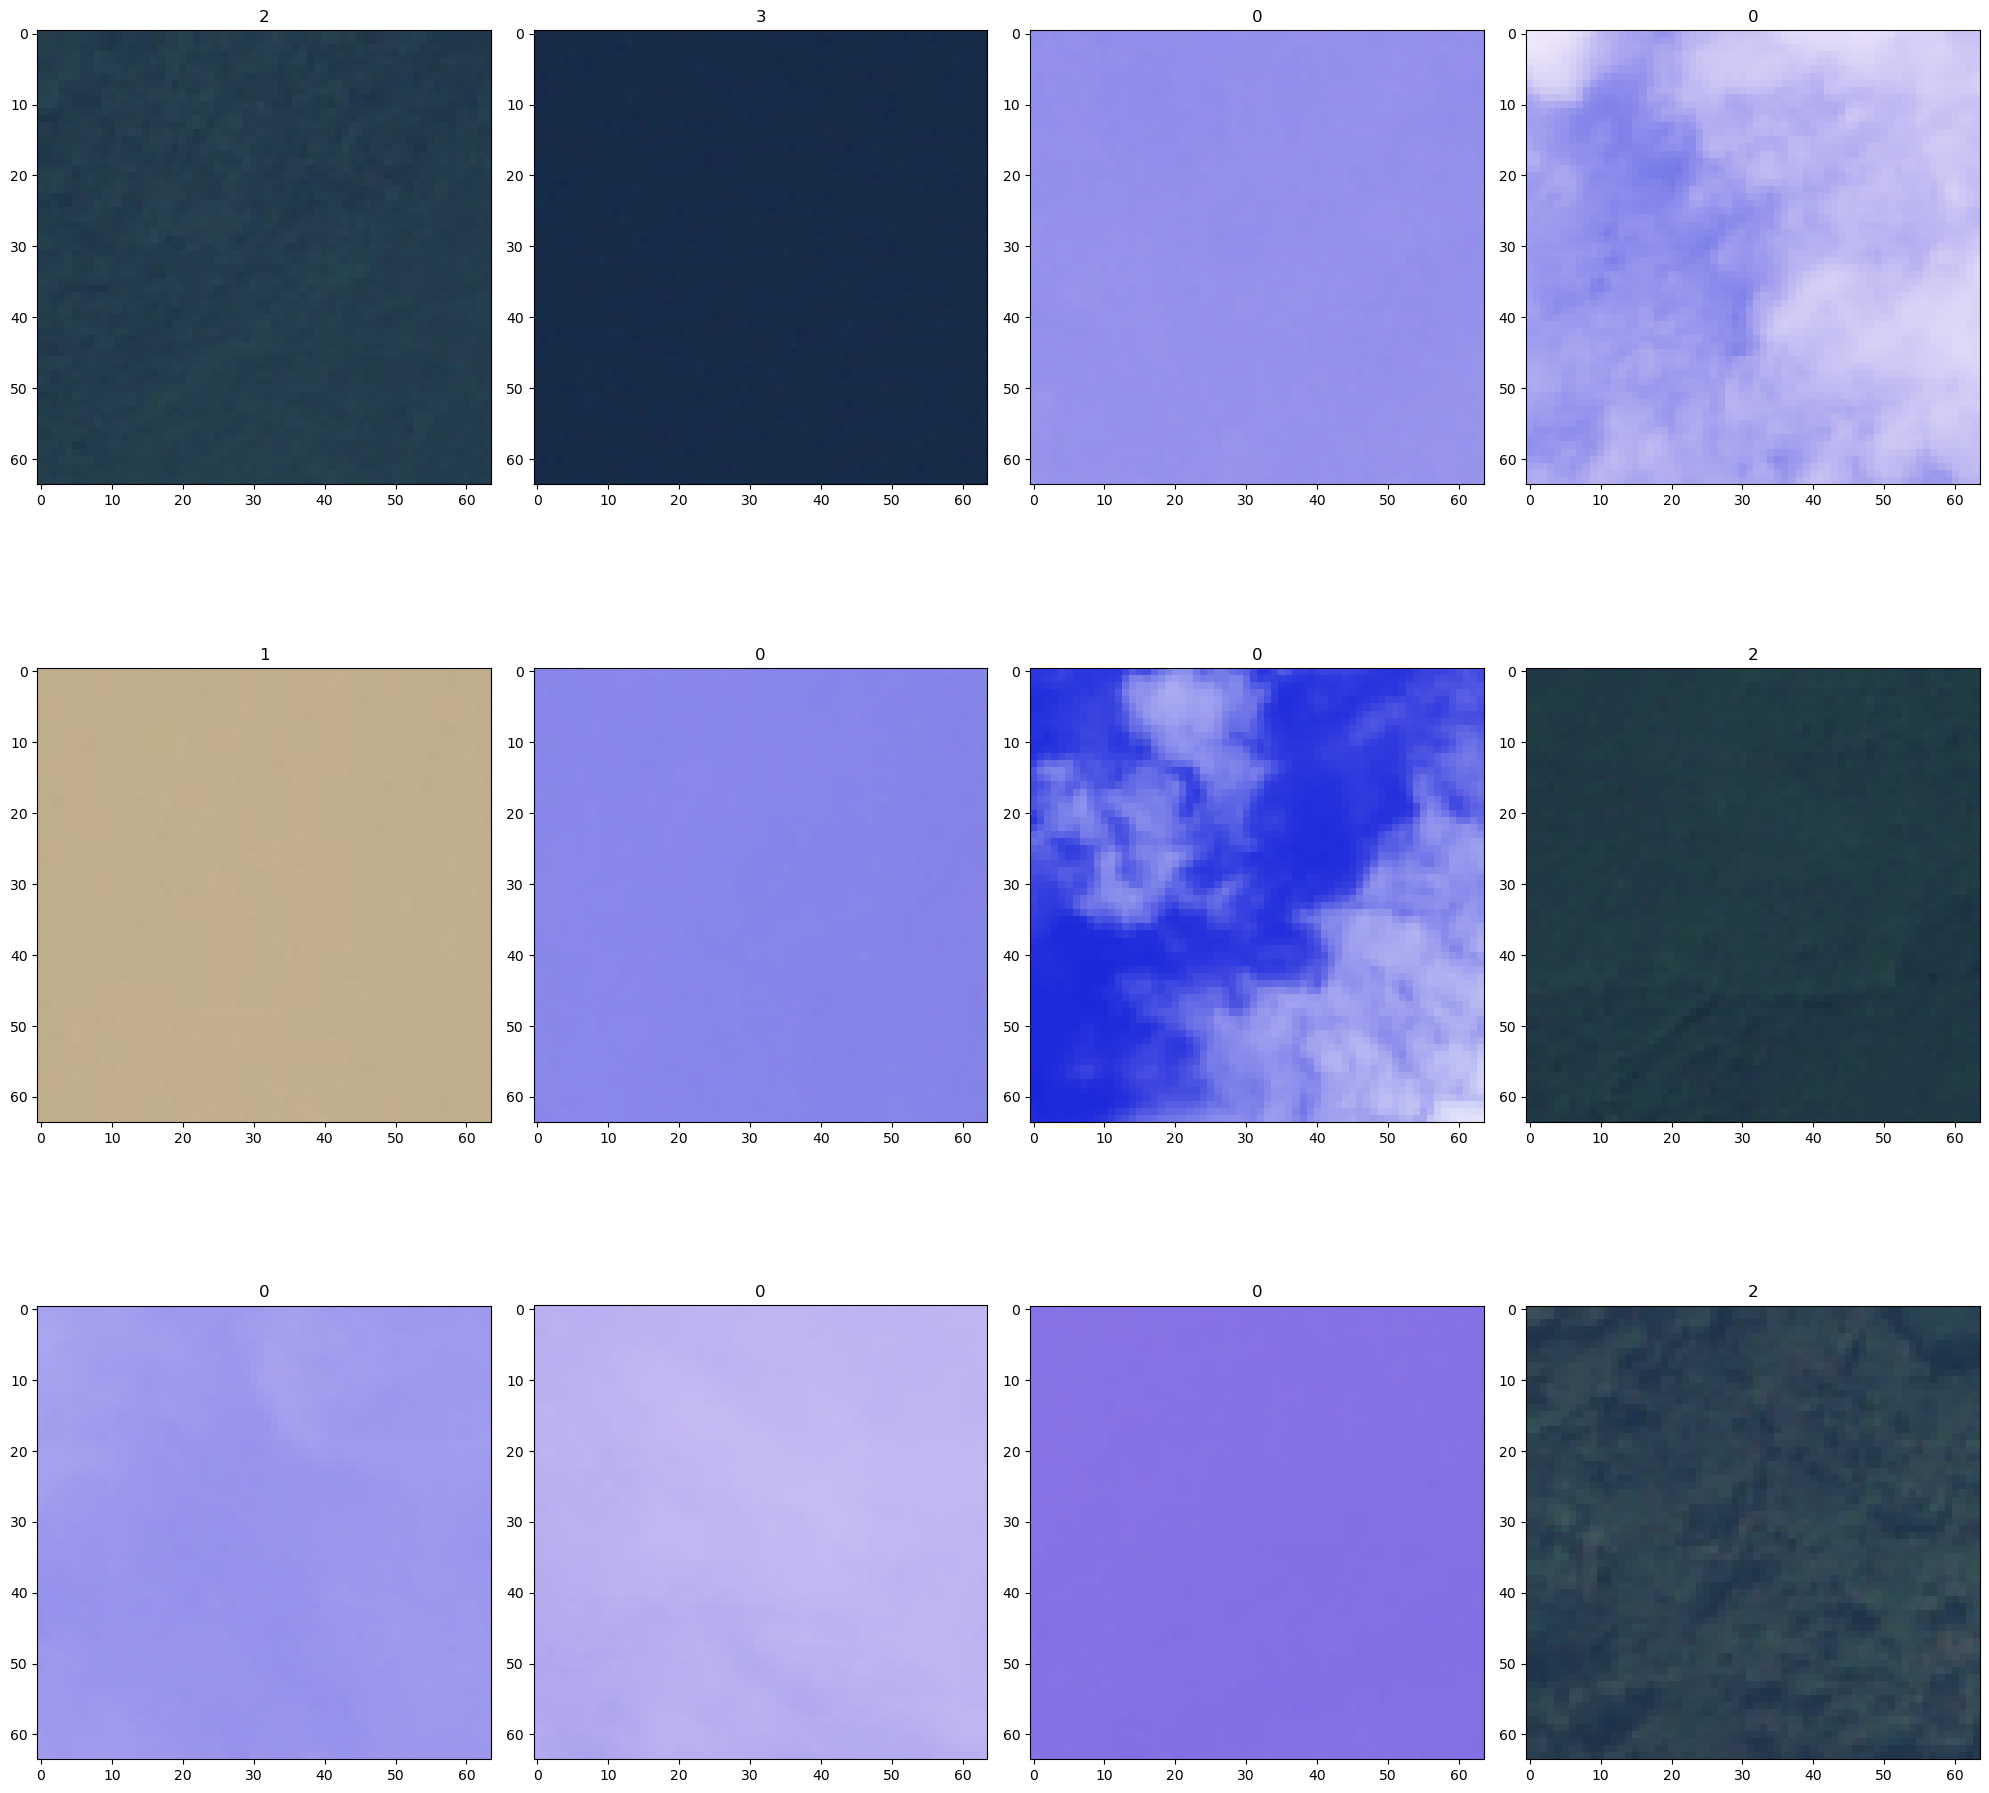

In [42]:
plt.figure(figsize = (20,20))
for i in range(12):
    plt.subplot(3,4,i+1)
    plt.imshow(X_test[i])
    plt.title(y_pred[i])
plt.tight_layout()
plt.show()

### Visualise confusion matrix on a heatmap

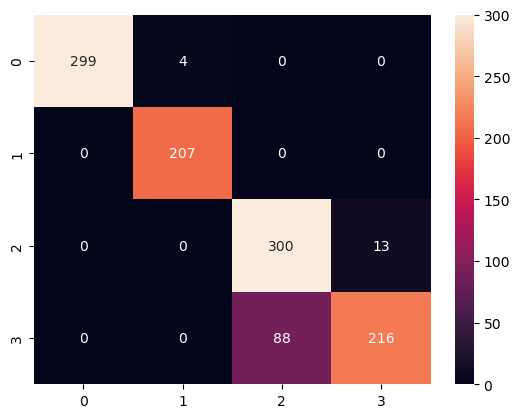

In [44]:
sns.heatmap(confusion_matrix(y_test,y_pred),  annot = True,fmt='d')
plt.show()

### Classification

In [45]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       1.00      0.99      0.99       303
           1       0.98      1.00      0.99       207
           2       0.77      0.96      0.86       313
           3       0.94      0.71      0.81       304

    accuracy                           0.91      1127
   macro avg       0.92      0.91      0.91      1127
weighted avg       0.92      0.91      0.91      1127

